# 1. 라이브러리 불러오기

In [79]:
# 기본적인 라이브러리
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from dataprep.eda import create_report

# 데이터 전처리에 관련된 함수
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import Normalizer
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler

# train과 test셋 분리하는 함수
from sklearn.model_selection import train_test_split

# 머신러닝 모델 함수
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier


# 최적의 하이퍼 파라미터 찾는 함수
from sklearn.model_selection import GridSearchCV

# 모델 평가 함수 및 기타 함수들...
from sklearn import metrics
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import cross_val_score
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# 경고문 끄기
import warnings
warnings.filterwarnings(action='ignore')

# 2. 데이터 불러오기

In [23]:
data = pd.read_csv('2022statcast.csv')

# 3. 데이터 살펴보기

### 3.1 column 정리하기

In [24]:
data.shape

(144, 15)

In [25]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   last_name           144 non-null    object 
 1    first_name         144 non-null    object 
 2   player_id           144 non-null    int64  
 3   year                144 non-null    int64  
 4   b_home_run          144 non-null    int64  
 5   xba                 144 non-null    float64
 6   xslg                144 non-null    float64
 7   xwoba               144 non-null    float64
 8   xobp                144 non-null    float64
 9   xiso                144 non-null    float64
 10  exit_velocity_avg   144 non-null    float64
 11  launch_angle_avg    144 non-null    float64
 12  barrel_batted_rate  144 non-null    float64
 13  hard_hit_percent    144 non-null    float64
 14  Unnamed: 14         0 non-null      float64
dtypes: float64(10), int64(3), object(2)
memory usage: 17.0+ K

In [26]:
pd.set_option('display.max_columns', None) # 모든 column 다 볼 수 있는 코드

data.head(15)

,last_name,first_name,player_id,year,b_home_run,xba,xslg,xwoba,xobp,xiso,exit_velocity_avg,launch_angle_avg,barrel_batted_rate,hard_hit_percent,Unnamed: 14
0,Cabrera,Miguel,408234,2022,4,0.240,0.337,0.282,0.298,0.097,89.9,4.2,4.7,38.3,NaN
1,Cruz Jr.,Nelson,443558,2022,9,0.247,0.416,0.330,0.331,0.169,90.9,7.3,10.5,48.0,NaN
2,Blackmon,Charlie,453568,2022,16,0.264,0.400,0.315,0.317,0.136,86.2,12.5,5.2,30.8,NaN
3,McCutchen,Andrew,457705,2022,11,0.259,0.407,0.325,0.328,0.147,89.4,12.8,7.8,40.9,NaN
4,Turner,Justin,457759,2022,8,0.248,0.396,0.317,0.325,0.147,89.5,18.7,7.3,39.8,NaN
5,Votto,Joey,458015,2022,11,0.218,0.393,0.325,0.333,0.174,89.8,14.3,11.3,41.4,NaN
6,Andrus,Elvis,462101,2022,7,0.229,0.322,0.276,0.292,0.093,88.3,13.4,3.4,33.4,NaN
7,Gurriel,Yuli,493329,2022,7,0.234,0.320,0.269,0.282,0.086,88.1,15.2,2.4,34.9,NaN
8,Rojas,Miguel,500743,2022,6,0.264,0.350,0.296,0.315,0.085,85.9,10.2,2.2,25.6,NaN
9,Escobar,Eduardo,500871,2022,12,0.226,0.382,0.290,0.281,0.156,88.3,20.6,7.9,36.2,NaN


In [27]:
# 필요없는 열 지우기

data.drop(['player_id', 'Unnamed: 14', 'year'], axis = 1, inplace = True)

In [28]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   last_name           144 non-null    object 
 1    first_name         144 non-null    object 
 2   b_home_run          144 non-null    int64  
 3   xba                 144 non-null    float64
 4   xslg                144 non-null    float64
 5   xwoba               144 non-null    float64
 6   xobp                144 non-null    float64
 7   xiso                144 non-null    float64
 8   exit_velocity_avg   144 non-null    float64
 9   launch_angle_avg    144 non-null    float64
 10  barrel_batted_rate  144 non-null    float64
 11  hard_hit_percent    144 non-null    float64
dtypes: float64(9), int64(1), object(2)
memory usage: 13.6+ KB


In [29]:
# column 이름 바꿔주기

data.rename(columns = {'b_home_run' : 'HR', 'exit_veloctiy_avg' : 'exit_velocity',
                      'launch_angle_avg' : 'launch_angle', 'barrel_batted_rate' :
                       'barrel_rate', 'hard_hit_percent' : 'hard_hit'},
           inplace = True)

In [30]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   last_name          144 non-null    object 
 1    first_name        144 non-null    object 
 2   HR                 144 non-null    int64  
 3   xba                144 non-null    float64
 4   xslg               144 non-null    float64
 5   xwoba              144 non-null    float64
 6   xobp               144 non-null    float64
 7   xiso               144 non-null    float64
 8   exit_velocity_avg  144 non-null    float64
 9   launch_angle       144 non-null    float64
 10  barrel_rate        144 non-null    float64
 11  hard_hit           144 non-null    float64
dtypes: float64(9), int64(1), object(2)
memory usage: 13.6+ KB


In [31]:
# 이름 합치기

data['name'] = data[' first_name'] + ' ' + data['last_name']
data.drop([' first_name', 'last_name'], axis = 1, inplace = True)

In [33]:
data.head(15).T

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14
HR,4,9,16,11,8,11,7,7,6,12,14,9,28,19,0
xba,0.24,0.247,0.264,0.259,0.248,0.218,0.229,0.234,0.264,0.226,0.24,0.272,0.265,0.26,0.248
xslg,0.337,0.416,0.4,0.407,0.396,0.393,0.322,0.32,0.35,0.382,0.398,0.477,0.498,0.419,0.325
xwoba,0.282,0.33,0.315,0.325,0.317,0.325,0.276,0.269,0.296,0.29,0.316,0.356,0.373,0.342,0.288
xobp,0.298,0.331,0.317,0.328,0.325,0.333,0.292,0.282,0.315,0.281,0.317,0.339,0.359,0.352,0.311
xiso,0.097,0.169,0.136,0.147,0.147,0.174,0.093,0.086,0.085,0.156,0.158,0.205,0.234,0.16,0.078
exit_velocity_avg,89.9,90.9,86.2,89.4,89.5,89.8,88.3,88.1,85.9,88.3,92.3,89.5,90.7,85.9,83.9
launch_angle,4.2,7.3,12.5,12.8,18.7,14.3,13.4,15.2,10.2,20.6,8.4,13.3,15.6,16.1,9.3
barrel_rate,4.7,10.5,5.2,7.8,7.3,11.3,3.4,2.4,2.2,7.9,7.9,12.7,12.3,7.6,2.2
hard_hit,38.3,48.0,30.8,40.9,39.8,41.4,33.4,34.9,25.6,36.2,49.3,43.5,46.6,29.5,28.5


In [36]:
# 열 바꾸기

col1 = data.columns[-1:].to_list()
col2 = data.columns[:-1].to_list()
new_col = col1 + col2

data = data[new_col]

In [37]:
data.head(15)

# 8월 16일 자 데이터

,name,HR,xba,xslg,xwoba,xobp,xiso,exit_velocity_avg,launch_angle,barrel_rate,hard_hit
0,Miguel Cabrera,4,0.240,0.337,0.282,0.298,0.097,89.9,4.2,4.7,38.3
1,Nelson Cruz Jr.,9,0.247,0.416,0.330,0.331,0.169,90.9,7.3,10.5,48.0
2,Charlie Blackmon,16,0.264,0.400,0.315,0.317,0.136,86.2,12.5,5.2,30.8
3,Andrew McCutchen,11,0.259,0.407,0.325,0.328,0.147,89.4,12.8,7.8,40.9
4,Justin Turner,8,0.248,0.396,0.317,0.325,0.147,89.5,18.7,7.3,39.8
5,Joey Votto,11,0.218,0.393,0.325,0.333,0.174,89.8,14.3,11.3,41.4
6,Elvis Andrus,7,0.229,0.322,0.276,0.292,0.093,88.3,13.4,3.4,33.4
7,Yuli Gurriel,7,0.234,0.320,0.269,0.282,0.086,88.1,15.2,2.4,34.9
8,Miguel Rojas,6,0.264,0.350,0.296,0.315,0.085,85.9,10.2,2.2,25.6
9,Eduardo Escobar,12,0.226,0.382,0.290,0.281,0.156,88.3,20.6,7.9,36.2


### 3.2 column들 살펴보기

In [39]:
data.sort_values('HR', ascending = False).head(15)

,name,HR,xba,xslg,xwoba,xobp,xiso,exit_velocity_avg,launch_angle,barrel_rate,hard_hit
43,Aaron Judge,46,0.300,0.705,0.456,0.398,0.405,95.5,14.0,26.5,60.4
98,Kyle Schwarber,34,0.233,0.550,0.377,0.335,0.318,92.8,18.4,21.4,52.3
135,Yordan Alvarez,31,0.326,0.669,0.460,0.429,0.344,95.4,12.3,20.3,60.9
105,Austin Riley,30,0.287,0.576,0.395,0.352,0.289,93.5,14.6,17.1,54.1
73,Pete Alonso,29,0.267,0.503,0.361,0.351,0.235,90.1,17.5,13.6,46.6
12,Paul Goldschmidt,28,0.265,0.498,0.373,0.359,0.234,90.7,15.6,12.3,46.6
36,Christian Walker,28,0.255,0.517,0.375,0.355,0.262,89.8,17.8,14.1,43.9
67,Byron Buxton,28,0.243,0.519,0.360,0.320,0.276,93.0,21.1,16.9,51.2
19,Anthony Rizzo,27,0.244,0.479,0.361,0.358,0.235,90.0,18.7,11.7,43.1
100,Shohei Ohtani,26,0.270,0.553,0.385,0.363,0.283,92.6,12.5,16.9,47.1


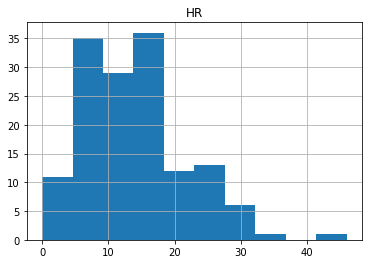

In [42]:
plt.title('HR')
data['HR'].hist(bins = 10)
plt.show()

In [43]:
data.sort_values('xba', ascending = False).head(15)

,name,HR,xba,xslg,xwoba,xobp,xiso,exit_velocity_avg,launch_angle,barrel_rate,hard_hit
135,Yordan Alvarez,31,0.326,0.669,0.460,0.429,0.344,95.4,12.3,20.3,60.9
17,Freddie Freeman,16,0.315,0.548,0.406,0.397,0.233,91.5,14.3,10.2,46.8
29,Jose Abreu,14,0.302,0.509,0.383,0.378,0.207,92.2,8.9,9.4,52.4
43,Aaron Judge,46,0.300,0.705,0.456,0.398,0.405,95.5,14.0,26.5,60.4
115,Alec Bohm,8,0.294,0.438,0.336,0.331,0.144,90.0,11.3,6.4,42.0
119,Vladimir Guerrero Jr.,24,0.292,0.495,0.370,0.364,0.202,93.0,5.2,11.5,52.8
90,Rafael Devers,25,0.291,0.530,0.373,0.348,0.239,93.5,11.1,12.8,51.9
91,Luis Arraez,6,0.290,0.417,0.342,0.361,0.127,89.2,12.1,4.0,32.1
60,Trea Turner,18,0.289,0.462,0.351,0.335,0.173,89.8,10.0,9.0,44.7
136,Alejandro Kirk,12,0.288,0.464,0.364,0.371,0.176,91.6,8.7,8.1,45.1


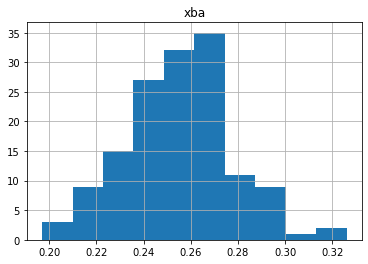

In [44]:
plt.title('xba')
data['xba'].hist(bins = 10)
plt.show()

In [45]:
data.sort_values('xslg', ascending = False).head(15)

,name,HR,xba,xslg,xwoba,xobp,xiso,exit_velocity_avg,launch_angle,barrel_rate,hard_hit
43,Aaron Judge,46,0.300,0.705,0.456,0.398,0.405,95.5,14.0,26.5,60.4
135,Yordan Alvarez,31,0.326,0.669,0.460,0.429,0.344,95.4,12.3,20.3,60.9
105,Austin Riley,30,0.287,0.576,0.395,0.352,0.289,93.5,14.6,17.1,54.1
100,Shohei Ohtani,26,0.270,0.553,0.385,0.363,0.283,92.6,12.5,16.9,47.1
98,Kyle Schwarber,34,0.233,0.550,0.377,0.335,0.318,92.8,18.4,21.4,52.3
17,Freddie Freeman,16,0.315,0.548,0.406,0.397,0.233,91.5,14.3,10.2,46.8
120,Juan Soto,22,0.275,0.532,0.417,0.431,0.257,90.5,8.3,12.6,46.7
90,Rafael Devers,25,0.291,0.530,0.373,0.348,0.239,93.5,11.1,12.8,51.9
63,Corey Seager,26,0.288,0.523,0.379,0.363,0.235,91.1,13.8,11.0,45.2
67,Byron Buxton,28,0.243,0.519,0.360,0.320,0.276,93.0,21.1,16.9,51.2


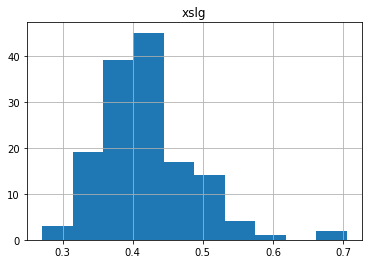

In [46]:
plt.title('xslg')
data['xslg'].hist(bins = 10)
plt.show()

In [47]:
data.sort_values('xwoba', ascending = False).head(15)

,name,HR,xba,xslg,xwoba,xobp,xiso,exit_velocity_avg,launch_angle,barrel_rate,hard_hit
135,Yordan Alvarez,31,0.326,0.669,0.460,0.429,0.344,95.4,12.3,20.3,60.9
43,Aaron Judge,46,0.300,0.705,0.456,0.398,0.405,95.5,14.0,26.5,60.4
120,Juan Soto,22,0.275,0.532,0.417,0.431,0.257,90.5,8.3,12.6,46.7
17,Freddie Freeman,16,0.315,0.548,0.406,0.397,0.233,91.5,14.3,10.2,46.8
105,Austin Riley,30,0.287,0.576,0.395,0.352,0.289,93.5,14.6,17.1,54.1
100,Shohei Ohtani,26,0.270,0.553,0.385,0.363,0.283,92.6,12.5,16.9,47.1
29,Jose Abreu,14,0.302,0.509,0.383,0.378,0.207,92.2,8.9,9.4,52.4
63,Corey Seager,26,0.288,0.523,0.379,0.363,0.235,91.1,13.8,11.0,45.2
98,Kyle Schwarber,34,0.233,0.550,0.377,0.335,0.318,92.8,18.4,21.4,52.3
101,Ronald Acuna Jr.,10,0.278,0.497,0.375,0.367,0.219,91.1,11.0,12.7,51.3


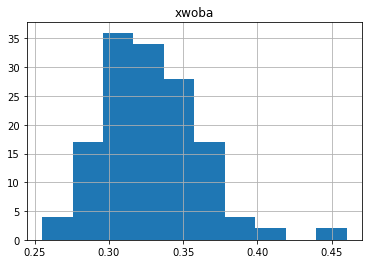

In [48]:
plt.title('xwoba')
data['xwoba'].hist(bins = 10)
plt.show()

In [49]:
data.sort_values('xobp', ascending = False).head(15)

,name,HR,xba,xslg,xwoba,xobp,xiso,exit_velocity_avg,launch_angle,barrel_rate,hard_hit
120,Juan Soto,22,0.275,0.532,0.417,0.431,0.257,90.5,8.3,12.6,46.7
135,Yordan Alvarez,31,0.326,0.669,0.460,0.429,0.344,95.4,12.3,20.3,60.9
43,Aaron Judge,46,0.300,0.705,0.456,0.398,0.405,95.5,14.0,26.5,60.4
17,Freddie Freeman,16,0.315,0.548,0.406,0.397,0.233,91.5,14.3,10.2,46.8
18,DJ LeMahieu,12,0.286,0.431,0.364,0.388,0.145,89.5,3.2,6.0,43.5
93,Yandy Diaz,6,0.273,0.393,0.352,0.387,0.120,91.5,6.7,4.2,46.0
29,Jose Abreu,14,0.302,0.509,0.383,0.378,0.207,92.2,8.9,9.4,52.4
55,Josh Bell,14,0.286,0.440,0.358,0.377,0.155,89.4,8.5,7.1,40.8
136,Alejandro Kirk,12,0.288,0.464,0.364,0.371,0.176,91.6,8.7,8.1,45.1
62,Alex Bregman,16,0.261,0.420,0.351,0.370,0.159,89.2,18.6,7.5,38.4


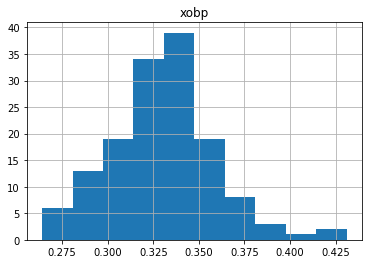

In [50]:
plt.title('xobp')
data['xobp'].hist(bins = 10)
plt.show()

In [52]:
data.sort_values('xiso', ascending = False).head(15)

,name,HR,xba,xslg,xwoba,xobp,xiso,exit_velocity_avg,launch_angle,barrel_rate,hard_hit
43,Aaron Judge,46,0.300,0.705,0.456,0.398,0.405,95.5,14.0,26.5,60.4
135,Yordan Alvarez,31,0.326,0.669,0.460,0.429,0.344,95.4,12.3,20.3,60.9
98,Kyle Schwarber,34,0.233,0.550,0.377,0.335,0.318,92.8,18.4,21.4,52.3
105,Austin Riley,30,0.287,0.576,0.395,0.352,0.289,93.5,14.6,17.1,54.1
100,Shohei Ohtani,26,0.270,0.553,0.385,0.363,0.283,92.6,12.5,16.9,47.1
67,Byron Buxton,28,0.243,0.519,0.360,0.320,0.276,93.0,21.1,16.9,51.2
36,Christian Walker,28,0.255,0.517,0.375,0.355,0.262,89.8,17.8,14.1,43.9
120,Juan Soto,22,0.275,0.532,0.417,0.431,0.257,90.5,8.3,12.6,46.7
81,Rowdy Tellez,24,0.261,0.501,0.358,0.343,0.241,90.9,15.9,13.3,44.4
90,Rafael Devers,25,0.291,0.530,0.373,0.348,0.239,93.5,11.1,12.8,51.9


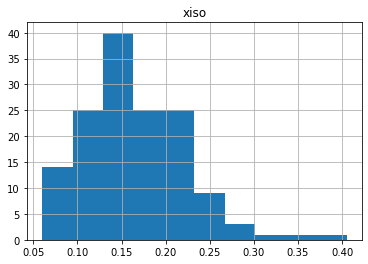

In [53]:
plt.title('xiso')
data['xiso'].hist(bins = 10)
plt.show()

In [54]:
data.sort_values('exit_velocity_avg', ascending = False).head(15)

,name,HR,xba,xslg,xwoba,xobp,xiso,exit_velocity_avg,launch_angle,barrel_rate,hard_hit
43,Aaron Judge,46,0.300,0.705,0.456,0.398,0.405,95.5,14.0,26.5,60.4
135,Yordan Alvarez,31,0.326,0.669,0.460,0.429,0.344,95.4,12.3,20.3,60.9
90,Rafael Devers,25,0.291,0.530,0.373,0.348,0.239,93.5,11.1,12.8,51.9
105,Austin Riley,30,0.287,0.576,0.395,0.352,0.289,93.5,14.6,17.1,54.1
94,Matt Chapman,23,0.248,0.477,0.355,0.330,0.229,93.1,21.5,14.8,54.0
67,Byron Buxton,28,0.243,0.519,0.360,0.320,0.276,93.0,21.1,16.9,51.2
119,Vladimir Guerrero Jr.,24,0.292,0.495,0.370,0.364,0.202,93.0,5.2,11.5,52.8
57,Teoscar Hernandez,17,0.265,0.492,0.350,0.317,0.227,92.9,12.3,13.3,54.2
98,Kyle Schwarber,34,0.233,0.550,0.377,0.335,0.318,92.8,18.4,21.4,52.3
100,Shohei Ohtani,26,0.270,0.553,0.385,0.363,0.283,92.6,12.5,16.9,47.1


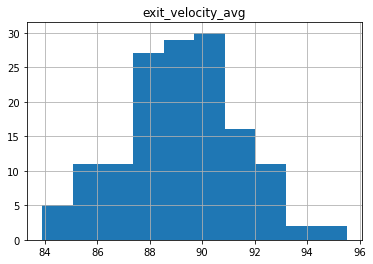

In [55]:
plt.title('exit_velocity_avg')
data['exit_velocity_avg'].hist(bins = 10)
plt.show()

In [56]:
data.sort_values('launch_angle', ascending = False).head(15)

,name,HR,xba,xslg,xwoba,xobp,xiso,exit_velocity_avg,launch_angle,barrel_rate,hard_hit
32,Nolan Arenado,25,0.259,0.444,0.336,0.331,0.185,88.7,22.8,9.0,39.7
49,Jorge Polanco,15,0.247,0.453,0.357,0.356,0.206,88.6,22.0,10.5,37.8
94,Matt Chapman,23,0.248,0.477,0.355,0.330,0.229,93.1,21.5,14.8,54.0
34,Max Muncy,14,0.200,0.413,0.338,0.341,0.213,89.9,21.4,14.9,44.3
69,Patrick Wisdom,21,0.197,0.398,0.308,0.298,0.201,91.1,21.2,14.7,47.9
61,Jose Ramirez,22,0.267,0.423,0.332,0.342,0.156,87.8,21.1,6.2,37.0
67,Byron Buxton,28,0.243,0.519,0.360,0.320,0.276,93.0,21.1,16.9,51.2
20,Wilmer Flores,16,0.243,0.383,0.317,0.329,0.140,88.4,21.1,6.1,35.6
76,Cody Bellinger,16,0.211,0.359,0.278,0.269,0.148,89.8,20.8,8.5,38.0
108,Kyle Tucker,21,0.268,0.495,0.367,0.352,0.227,89.2,20.7,10.5,39.2


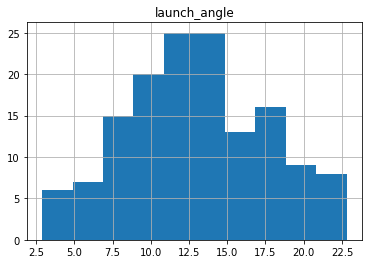

In [57]:
plt.title('launch_angle')
data['launch_angle'].hist(bins = 10)
plt.show()

In [58]:
data.sort_values('barrel_rate', ascending = False).head(15)

,name,HR,xba,xslg,xwoba,xobp,xiso,exit_velocity_avg,launch_angle,barrel_rate,hard_hit
43,Aaron Judge,46,0.300,0.705,0.456,0.398,0.405,95.5,14.0,26.5,60.4
98,Kyle Schwarber,34,0.233,0.550,0.377,0.335,0.318,92.8,18.4,21.4,52.3
135,Yordan Alvarez,31,0.326,0.669,0.460,0.429,0.344,95.4,12.3,20.3,60.9
105,Austin Riley,30,0.287,0.576,0.395,0.352,0.289,93.5,14.6,17.1,54.1
100,Shohei Ohtani,26,0.270,0.553,0.385,0.363,0.283,92.6,12.5,16.9,47.1
67,Byron Buxton,28,0.243,0.519,0.360,0.320,0.276,93.0,21.1,16.9,51.2
35,Luke Voit III,15,0.220,0.440,0.330,0.315,0.220,90.3,18.4,16.0,45.1
34,Max Muncy,14,0.200,0.413,0.338,0.341,0.213,89.9,21.4,14.9,44.3
94,Matt Chapman,23,0.248,0.477,0.355,0.330,0.229,93.1,21.5,14.8,54.0
69,Patrick Wisdom,21,0.197,0.398,0.308,0.298,0.201,91.1,21.2,14.7,47.9


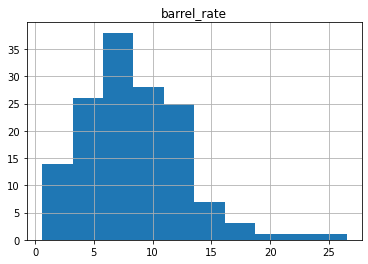

In [59]:
plt.title('barrel_rate')
data['barrel_rate'].hist(bins = 10)
plt.show()

In [60]:
data.sort_values('hard_hit', ascending = False).head(15)

,name,HR,xba,xslg,xwoba,xobp,xiso,exit_velocity_avg,launch_angle,barrel_rate,hard_hit
135,Yordan Alvarez,31,0.326,0.669,0.460,0.429,0.344,95.4,12.3,20.3,60.9
43,Aaron Judge,46,0.300,0.705,0.456,0.398,0.405,95.5,14.0,26.5,60.4
57,Teoscar Hernandez,17,0.265,0.492,0.350,0.317,0.227,92.9,12.3,13.3,54.2
105,Austin Riley,30,0.287,0.576,0.395,0.352,0.289,93.5,14.6,17.1,54.1
94,Matt Chapman,23,0.248,0.477,0.355,0.330,0.229,93.1,21.5,14.8,54.0
119,Vladimir Guerrero Jr.,24,0.292,0.495,0.370,0.364,0.202,93.0,5.2,11.5,52.8
29,Jose Abreu,14,0.302,0.509,0.383,0.378,0.207,92.2,8.9,9.4,52.4
98,Kyle Schwarber,34,0.233,0.550,0.377,0.335,0.318,92.8,18.4,21.4,52.3
90,Rafael Devers,25,0.291,0.530,0.373,0.348,0.239,93.5,11.1,12.8,51.9
101,Ronald Acuna Jr.,10,0.278,0.497,0.375,0.367,0.219,91.1,11.0,12.7,51.3


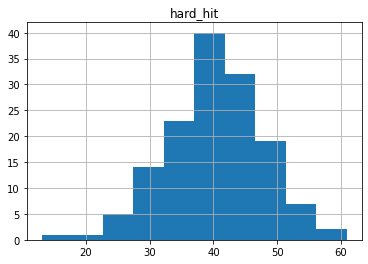

In [61]:
plt.title('hard_hit')
data['hard_hit'].hist(bins = 10)
plt.show()

### 3.3 상관계수 확인하기

In [62]:
# 숫자형 변수만 추출

data_num = data.drop('name', axis = 1)

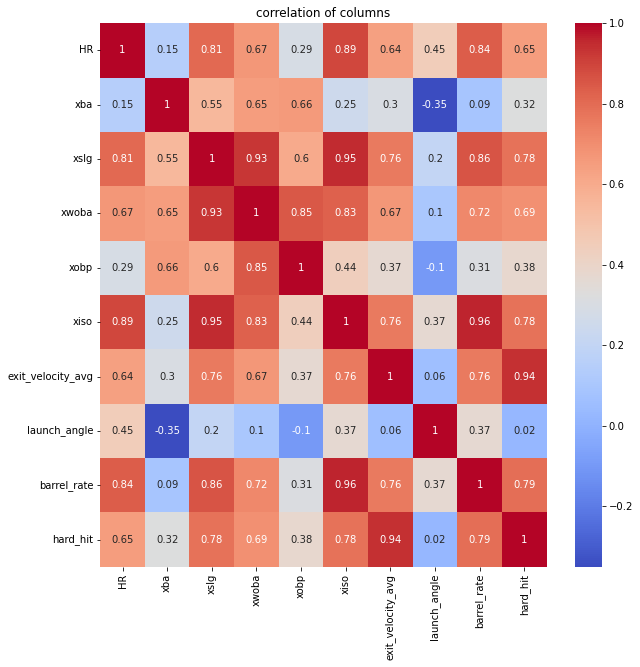

In [66]:
corr = round(data_num.corr(), 2)

plt.figure(figsize = (10, 10))
sns.heatmap(corr, cmap = 'coolwarm', annot = True)
plt.title('correlation of columns')
plt.show()

In [67]:
vif=pd.DataFrame()
vif['VIF Factor'] = [variance_inflation_factor(data_num.values, i) for i in range(data_num.shape[1])]
vif['features'] = data_num.columns
vif

# 홈런 개수 예측해보기

,VIF Factor,features
0,24.008610,HR
1,294022.065331,xba
2,795942.336281,xslg
3,26106.472480,xwoba
4,7685.771669,xobp
5,133114.911513,xiso
6,508.407028,exit_velocity_avg
7,18.085128,launch_angle
8,120.162858,barrel_rate
9,121.297216,hard_hit


# 4. 홈런 개수 예측해보기

### 4.1 모든 feature 다 사용해보기

In [73]:
# target은 홈런

X = data.drop(['name','HR'], axis = 1)
y = data['HR']

In [74]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3)

In [75]:
lr = LinearRegression()

In [76]:
lr.fit(X_train, y_train)

LinearRegression()

In [78]:
pred1 = lr.predict(X_test)

In [80]:
print(mean_absolute_error(y_test, pred1))
print(mean_squared_error(y_test, pred1))
print(r2_score(y_test, pred1))

2.668690867517157
12.98868510455472
0.7330874912439318


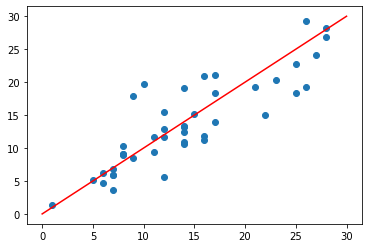

In [85]:
plt.scatter(y_test, pred1)
plt.plot([0, 30], [0, 30], 'r-')
plt.show()